In [17]:
from __future__ import annotations
import warnings
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


# ─────────────────────────────────────────────────────────────────────────────
# Analytical SR-equivalents
# ─────────────────────────────────────────────────────────────────────────────
def assr_eq(SR, skew):
    """SR-equivalent under ASSR = SR · √(1 + skew·SR/3).  NaN past the CARA boundary."""
    inside = 1.0 + skew * SR / 3.0
    return np.where(inside > 0, SR * np.sqrt(np.maximum(inside, 0.0)), np.nan)


def psr_skew_eq(SR, skew):
    """
    SR-equivalent under PSR_skew (sr_star = 0):
        SR_eq = c · √(2/(2−c²)),   c = SR/√(1 − skew·SR + SR²/2),   valid for c²<2.
    The (T−1) factor cancels — this is T-independent.
    """
    var = 1.0 - skew * SR + 0.5 * SR**2
    var = np.maximum(var, 1e-12)
    c   = SR / np.sqrt(var)
    c2  = c * c
    return np.where(c2 < 2.0,
                    c * np.sqrt(2.0 / np.maximum(2.0 - c2, 1e-12)),
                    np.nan)


# ─────────────────────────────────────────────────────────────────────────────
# Plot — indifference curves
# ─────────────────────────────────────────────────────────────────────────────
def plot_indifference_curves(
    ref_SRs=(0.15, 0.25, 0.35, 0.45),
    skew_ref=0.0,
    SR_range=(0.05, 0.60),
    skew_range=(-5.0, 1.5),
    ax=None,
    n_pts=600,
):
    """
    Plot indifference curves of PSR_normal, PSR_skew, ASSR through each (SR_ref, skew_ref).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(7.5, 6))
 
    SR_min, SR_max_global = SR_range
 
    for k, SR_ref in enumerate(ref_SRs):
        # PSR_skew: monotonic for all SR > 0 → use the full SR_range.
        SR_psr = np.linspace(SR_min, SR_max_global, n_pts)
        skew_psr = (SR_ref**2 - SR_psr**2) / (SR_ref**2 * SR_psr) + skew_ref*(SR_psr/SR_ref)
 
        # ASSR: clip at SR = √3·SR_ref (the principal-branch upper limit).
        SR_max_assr = min(SR_ref * np.sqrt(3.0), SR_max_global)
        SR_assr = np.linspace(SR_min, SR_max_assr, n_pts)
        skew_assr = 3.0 * (SR_ref**2 - SR_assr**2) / SR_assr**3 + skew_ref*(SR_ref/SR_assr)**3
 
        lbl_a = 'ASSR  indifference'                          if k == 0 else None
        lbl_p = r'PSR$_{\rm skew}$  indifference'             if k == 0 else None
        lbl_n = r'PSR$_{\rm normal}$ indifference' if k == 0 else None
 
        ax.plot(SR_assr, skew_assr, color='C3', lw=1.6, alpha=0.9, label=lbl_a)
        ax.plot(SR_psr,  skew_psr,  color='C0', lw=1.6, alpha=0.9, label=lbl_p)
        ax.axvline(SR_ref, color='gray', ls='--', lw=1.6, alpha=0.7, label=lbl_n)
 
        # Shade the disagreement band on the overlap of the two SR ranges
        SR_common = SR_assr
        skew_psr_common  = (SR_ref**2 - SR_common**2) / (SR_ref**2 * SR_common) + skew_ref*(SR_common/SR_ref)
        skew_assr_common = 3.0 * (SR_ref**2 - SR_common**2) / SR_common**3 + skew_ref*(SR_ref/SR_common)**3
        lower = np.minimum(skew_assr_common, skew_psr_common)
        upper = np.maximum(skew_assr_common, skew_psr_common)
        ax.fill_between(SR_common, lower, upper, color='gray', alpha=0.10)
 
        ax.plot(SR_ref, skew_ref, 'ko', markersize=4)
        y_label = skew_range[1] - 0.15 * (skew_range[1] - skew_range[0]) * 0.3
        ax.annotate(f'{SR_ref}', xy=(SR_ref, skew_range[1] * 0.4),
                    ha='center', fontsize=9, color='black')
 
    ax.set_xlim(*SR_range)
    ax.set_ylim(*skew_range)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_xlabel('Sharpe ratio')
    ax.set_ylabel('Skew')
    ax.set_title('Indifference curves through reference points (SR$_{\\rm ref}$, Skew$_{\\rm ref}$)')
    ax.legend(loc='lower right', framealpha=0.92)
    ax.grid(alpha=0.3)
    return ax

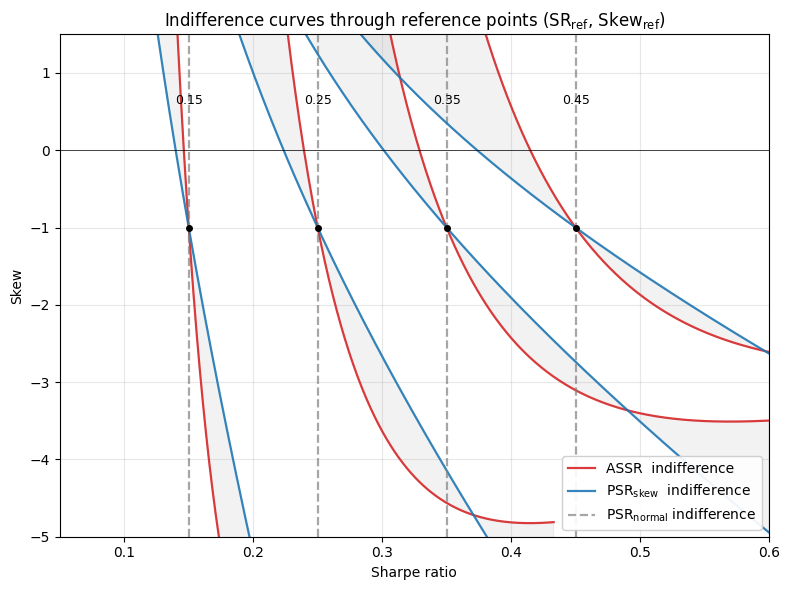

In [18]:
from config import PLOTS_DIR

fig, ax = plt.subplots(figsize=(8, 6))
plot_indifference_curves(ax=ax, ref_SRs=(0.15, 0.25, 0.35, 0.45), skew_ref=-1.0)
fig.tight_layout()
plt.savefig(PLOTS_DIR / "indiff_curve.png", dpi=130, bbox_inches='tight')
fig.show()

In [ ]:

import numpy as np
import pandas as pd
from scipy.stats import norm, spearmanr

# ── Settings ─────────────────────────────────────────────────────────────
T       = 50      # only affects PSR magnitudes, not their rankings
sr_star = 0.0

# ── Portfolios: (SR, skew) ───────────────────────────────────────────────
portfolios = [
    ("P1", 0.15, -1.0),
    ("P2", 0.16, -5.0),
    ("P3", 0.25, -1.0),
    ("P4", 0.3, -4.0),
    ("P5", 0.35,  -1.0),
    ("P6", 0.4, -3),
    ("P7", 0.45,  -1.0),
    ("P8", 0.5, -2),
]

# ── Metrics (theoretical moments fed in directly) ────────────────────────
def psr_normal(SR, T, sr_star=0.0):
    V = (1.0 + SR**2 / 2.0) / (T - 1)
    return norm.cdf((SR - sr_star) / np.sqrt(V))

def psr_skew(SR, skew, T, sr_star=0.0):
    V = (1.0 - skew * SR + SR**2 / 2.0) / (T - 1)
    return norm.cdf((SR - sr_star) / np.sqrt(V))

def assr(SR, skew):
    return SR * np.sqrt(1.0 + skew * SR / 3.0)

# ── Build the table ──────────────────────────────────────────────────────
df = pd.DataFrame(
    [{"Portfolio": n, "SR": s, "Skew": k,
      "PSR_normal": psr_normal(s, T, sr_star),
      "PSR_skew":   psr_skew(s, k, T, sr_star),
      "ASSR":       assr(s, k)} for n, s, k in portfolios]
)

# Rankings (1 = best)
df["Rk_PSR_normal"] = df["PSR_normal"].rank(ascending=False).astype(int)
df["Rk_PSR_skew"]   = df["PSR_skew"]  .rank(ascending=False).astype(int)
df["Rk_ASSR"]       = df["ASSR"]      .rank(ascending=False).astype(int)

# ── Display ──────────────────────────────────────────────────────────────
print(f"Table 1 — moments and metric values   (T={T}, sr_star={sr_star})")
print("-" * 64)
print(df[["Portfolio", "SR", "Skew", "PSR_normal", "PSR_skew", "ASSR"]]
        .to_string(index=False,
                   formatters={"SR":"{:.2f}".format, "Skew":"{:+.2f}".format,
                               "PSR_normal":"{:.4f}".format,
                               "PSR_skew":"{:.4f}".format,
                               "ASSR":"{:.4f}".format}))

print()
print("Table 2 — rankings (1 = best)")
print("-" * 64)
print(df[["Portfolio", "Rk_PSR_normal", "Rk_PSR_skew", "Rk_ASSR"]]
        .to_string(index=False))

# ── Spearman correlations vs ASSR ranks ──────────────────────────────────
rho_n, _ = spearmanr(df["Rk_PSR_normal"], df["Rk_ASSR"])
rho_s, _ = spearmanr(df["Rk_PSR_skew"],   df["Rk_ASSR"])

print()
print("Spearman correlations with ASSR ranks")
print("-" * 64)
print(f"  ρ(PSR_normal, ASSR) = {rho_n:+.4f}")
print(f"  ρ(PSR_skew,   ASSR) = {rho_s:+.4f}")
print(f"  Δρ = ρ_skew − ρ_normal = {rho_s - rho_n:+.4f}")

Table 1 — moments and metric values   (T=50, sr_star=0.0)
----------------------------------------------------------------
Portfolio   SR  Skew PSR_normal PSR_skew   ASSR
       P1 0.15 -1.00     0.8518   0.8351 0.1462
       P2 0.16 -5.00     0.8671   0.7973 0.1370
       P3 0.25 -1.00     0.9576   0.9390 0.2394
       P4 0.30 -4.00     0.9800   0.9195 0.2324
       P5 0.35 -1.00     0.9913   0.9804 0.3290
       P6 0.40 -3.00     0.9965   0.9682 0.3098
       P7 0.45 -1.00     0.9987   0.9943 0.4149
       P8 0.50 -2.00     0.9995   0.9918 0.4082

Table 2 — rankings (1 = best)
----------------------------------------------------------------
Portfolio  Rk_PSR_normal  Rk_PSR_skew  Rk_ASSR
       P1              8            7        7
       P2              7            8        8
       P3              6            5        5
       P4              5            6        6
       P5              4            3        3
       P6              3            4        4
       P7           